In [1]:
import pandas as pd
import geopandas as gpd
from shapely.geometry import Point
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import duckdb
import scipy.stats as stats
import seaborn as sns
import plotly.io as pio
pio.renderers.default = "notebook"  

# Change working directory
import os
os.chdir(os.getcwd() + "/../")

import config
from visualisation.plotting import plot_geo

## Load data

In [2]:
# Load ocean region data (remove noise label)
regions_df = pd.read_csv(f"{config.output_dir}cluster_set.csv")
regions_df = regions_df[regions_df.label != 8]

# Ensure numeric depth
regions_df["LEV_M"] = pd.to_numeric(regions_df["LEV_M"], errors="coerce")

# Create 3D Point Geometry (longitude, latitude, depth)
regions_df["geometry"] = regions_df.apply(lambda row: Point(row["LONGITUDE"], row["LATITUDE"], row["LEV_M"]), axis=1)

# Convert to a GeoDataFrame
regions_gfdf = gpd.GeoDataFrame(regions_df, geometry="geometry", crs="EPSG:4326")


In [3]:
# Load species and ocean region data
# Connect to DuckDB (in-memory by default)
con = duckdb.connect()

# Query the Parquet files
species_df = con.execute(f"""
    SELECT AphiaID, genus, species, scientificName, decimalLongitude, decimalLatitude, minimumDepthInMeters, maximumDepthInMeters 
    FROM read_parquet('../../data/OBIS_20250318_parquet/occurrence/*.parquet') 
    WHERE dropped = 'False' AND (genus IS NOT NULL OR species IS NOT NULL) AND minimumDepthInMeters >= 0 AND minimumDepthInMeters IS NOT NULL
    AND decimalLatitude >= {config.grid_config["lat_min"]} AND decimalLatitude <= {config.grid_config["lat_max"]} 
    AND decimalLongitude >= {config.grid_config["lon_min"]} AND decimalLongitude <= {config.grid_config["lon_max"]}  
""").fetchdf()  # Fetch result as a Pandas DataFrame

# Close the connection
con.close()

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

In [4]:
# Drop species without depths
species_df = species_df[(~species_df["minimumDepthInMeters"].isna()) | (~species_df["maximumDepthInMeters"].isna())]

# Ensure numeric depth values
species_df["minimumDepthInMeters"] = pd.to_numeric(species_df["minimumDepthInMeters"], errors="coerce")
species_df["maximumDepthInMeters"] = pd.to_numeric(species_df["maximumDepthInMeters"], errors="coerce")

In [5]:
# Map latitude
lat_bins = np.arange(config.grid_config["lat_min"], config.grid_config["lat_max"] + config.grid_config["dlat"], config.grid_config["dlat"]).astype(float)
lat_bins[-1] = lat_bins[-1] + 0.001 * (1 if lat_bins[-1] >= 0 else -1)
species_df["LATITUDE"] = pd.cut(species_df["decimalLatitude"], bins=lat_bins, right=False, labels=lat_bins[:-1] + config.grid_config["dlat"] / 2)

# Map longitude
lon_bins = np.arange(config.grid_config["lon_min"], config.grid_config["lon_max"] + config.grid_config["dlon"], config.grid_config["dlon"]).astype(float)
lon_bins[-1] = lon_bins[-1] + 0.001 * (1 if lon_bins[-1] >= 0 else -1)
species_df["LONGITUDE"] = pd.cut(species_df["decimalLongitude"], bins=lon_bins, right=False, labels=lon_bins[:-1] + config.grid_config["dlon"] / 2)

# Map depth
if config.grid_config["z_array"] is not None:
    z_bins = config.grid_config["z_array"].astype(float) 
else:
    z_bins = np.arange(config.grid_config["z_min"], config.grid_config["z_max"] + config.grid_config["dz"], config.grid_config["dz"]).astype(float)

if len(z_bins) == 1:
    species_df["LEV_M"] = z_bins[0]
else:
    z_bins[-1] = z_bins[-1] + 0.001  # make sure, last values are included while cutting using pandas
    species_df["LEV_M"] = pd.cut(species_df["minimumDepthInMeters"], bins=z_bins, right=False, labels=z_bins[:-1])

# Ensure proper datatypes
species_df["LATITUDE"] = species_df["LATITUDE"].astype(float)
species_df["LONGITUDE"] = species_df["LONGITUDE"].astype(float)
species_df["LEV_M"] = species_df["LEV_M"].astype(float)

In [6]:
# Remove too deep animals (and thus did not get mapped to a depth level)
species_df = species_df[~species_df.LEV_M.isna()]

In [7]:
species_df.head()

,aphiaid,genus,species,scientificName,decimalLongitude,decimalLatitude,minimumDepthInMeters,maximumDepthInMeters,LATITUDE,LONGITUDE,LEV_M
0,326622,Aricidea,Aricidea tetrabranchia,Aricidea tetrabranchia,-19.15,36.81,4930.0,NaN,36.5,-19.5,4000.0
3,130147,Progoniada,Progoniada regularis,Progoniada regularis,-15.63,37.33,4490.0,NaN,37.5,-15.5,4000.0
5,331488,Rhamphobrachium,Rhamphobrachium agassizi,Rhamphobrachium agassizi,-16.00,62.00,2192.0,NaN,62.5,-15.5,2000.0
6,130530,Phylo,Phylo kupfferi,Phylo kupfferi,-10.98,54.90,2433.0,NaN,54.5,-10.5,2000.0
7,130542,Myriochele,Myriochele heeri,Myriochele heeri,1.08,65.47,2730.0,NaN,65.5,1.5,2000.0


## Assign species to ocean regions

In [9]:
# Ensure consistent precision before joining
species_df[["LATITUDE", "LONGITUDE", "LEV_M"]] = species_df[["LATITUDE", "LONGITUDE", "LEV_M"]].round(1)
regions_df[["LATITUDE", "LONGITUDE", "LEV_M"]] = regions_df[["LATITUDE", "LONGITUDE", "LEV_M"]].round(1)

In [10]:
# Merge species with regions based on latitude, longitude, and depth bin
species_with_regions = species_df.merge(
    regions_df[["LATITUDE", "LONGITUDE", "LEV_M", "label"]], 
    how="left",
    left_on=["LATITUDE", "LONGITUDE", "LEV_M"],
    right_on=["LATITUDE", "LONGITUDE", "LEV_M"]
)

In [11]:
# Remove cells without labels
species_with_regions = species_with_regions[~species_with_regions.label.isna()]

In [12]:
species_with_regions.head()

,aphiaid,genus,species,scientificName,decimalLongitude,decimalLatitude,minimumDepthInMeters,maximumDepthInMeters,LATITUDE,LONGITUDE,LEV_M,label
0,326622,Aricidea,Aricidea tetrabranchia,Aricidea tetrabranchia,-19.15,36.81,4930.0,NaN,36.5,-19.5,4000.0,2.0
1,130147,Progoniada,Progoniada regularis,Progoniada regularis,-15.63,37.33,4490.0,NaN,37.5,-15.5,4000.0,2.0
2,331488,Rhamphobrachium,Rhamphobrachium agassizi,Rhamphobrachium agassizi,-16.00,62.00,2192.0,NaN,62.5,-15.5,2000.0,3.0
3,130530,Phylo,Phylo kupfferi,Phylo kupfferi,-10.98,54.90,2433.0,NaN,54.5,-10.5,2000.0,7.0
4,130542,Myriochele,Myriochele heeri,Myriochele heeri,1.08,65.47,2730.0,NaN,65.5,1.5,2000.0,14.0


## Analysis: Species recordings

In [13]:
print(f"There are {len(species_with_regions)} species recordings left.")

There are 20237771 species recordings left.


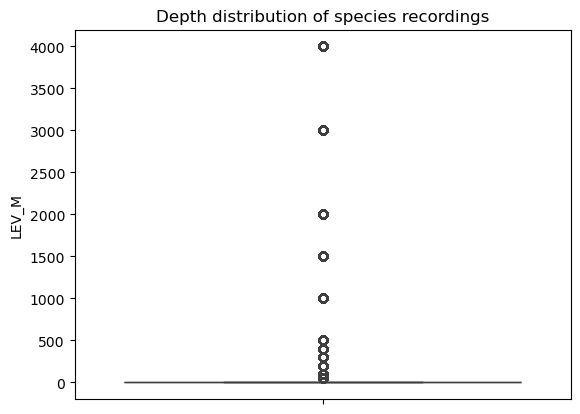

In [14]:
sns.boxplot(species_with_regions.LEV_M)
plt.title("Depth distribution of species recordings")
plt.show()
# --> Very few measurements below 500m

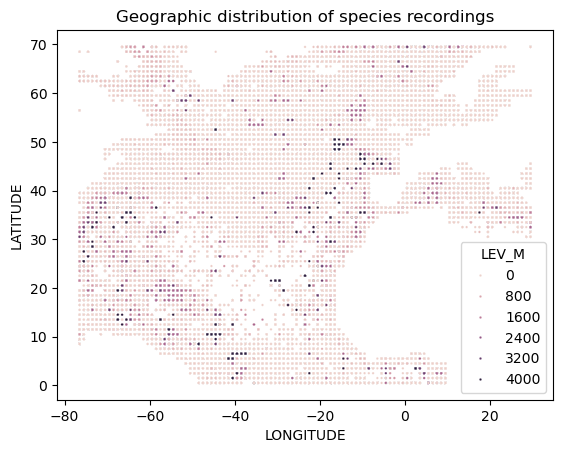

In [51]:
sns.scatterplot(species_with_regions, x="LONGITUDE", y="LATITUDE", hue="LEV_M", s=3)
plt.title("Geographic distribution of species recordings")
plt.show()

## Analysis: Endemicity

In [16]:
# Determine which taxonomic level to investigate
level = "aphiaid"

In [17]:
# Filter data for species occurring only in one region
# Count the number of unique 3D regions per species
species_3d_counts = species_with_regions.groupby(level)[["LONGITUDE", "LATITUDE", "LEV_M"]].nunique()

# Identify endemic species (only found in one 3D region)
endemic_3d_species = species_3d_counts[(species_3d_counts == 1).all(axis=1)].index

# Filter data for 3D-endemic species
endemic_3d_species_data = species_with_regions[species_with_regions[level].isin(endemic_3d_species)]

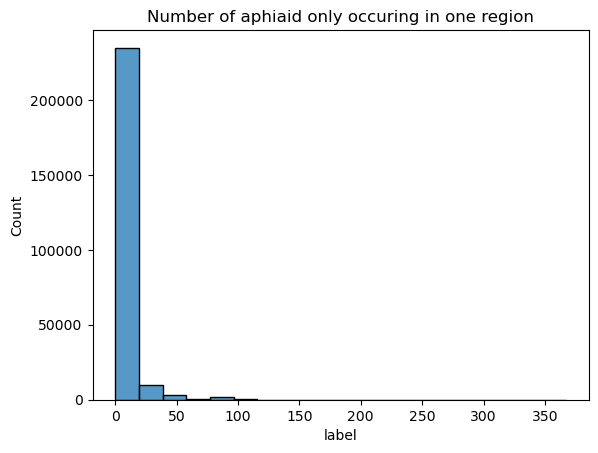

In [18]:
sns.histplot(endemic_3d_species_data.label)
plt.title(f"Number of {level} only occuring in one region")
plt.show()

### Endemicity per ocean region

In [19]:
# Count total species occurrences per ocean region
total_species_per_region = species_with_regions.groupby("label")[level].nunique()

# Count endemic species per ocean region
endemic_species_per_region = endemic_3d_species_data.groupby("label")[level].nunique()

# Compute endemicity percentage per region
endemicity_percentage = (endemic_species_per_region / total_species_per_region) * 100

# Convert to a DataFrame for easy viewing
endemicity_df = endemicity_percentage.reset_index().rename(columns={level: "Endemicity_Percentage"})


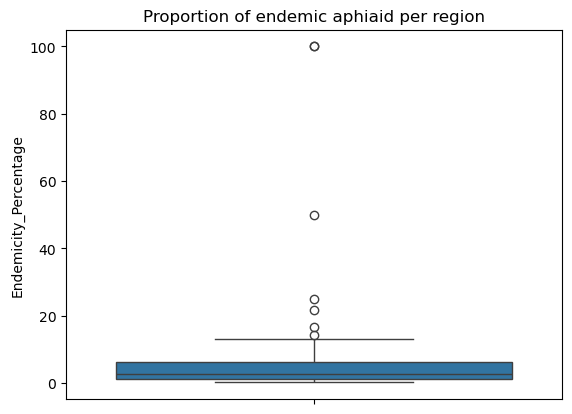

Mean endemicity for the regions: 5.63%


In [20]:
sns.boxplot(endemicity_df.Endemicity_Percentage)
plt.title(f"Proportion of endemic {level} per region")
plt.show()

print(f"Mean endemicity for the regions: {round(endemicity_df.Endemicity_Percentage.mean(), 2)}%")

### Clusters with >= 10% enedmic species

In [21]:
# Clusters with >= 10% endemic species
endemicity_df[endemicity_df.Endemicity_Percentage >= 10].sort_values("Endemicity_Percentage", ascending=False)

,label,Endemicity_Percentage
175,202.0,100.000000
224,264.0,100.000000
215,249.0,50.000000
258,318.0,25.000000
0,0.0,21.568506
211,245.0,16.666667
250,303.0,14.285714
89,94.0,13.175355
79,83.0,12.820513
214,248.0,12.195122


In [47]:
# Check which Mediterranean labels appear in the endemic-clusters list
lon_min = -6
lon_max = 30
lat_min = 30
lat_max = 48

medi = regions_df[(regions_df.LONGITUDE <= lon_max) &  (regions_df.LONGITUDE >= lon_min) & (regions_df.LATITUDE <= lat_max) & (regions_df.LATITUDE >= lat_min)]
medi = medi.drop(medi[(medi.LONGITUDE < 0) & (medi.LATITUDE > 42)].index)  # cut out Biskay
medi = medi.drop(medi[(medi.LONGITUDE > 27) & (medi.LATITUDE > 40)].index) # cut out Red Sea

medi_endemic = [x for x in medi.label.unique() if x in list(endemicity_df[endemicity_df.Endemicity_Percentage >= 10].label.astype(int))]

print(f"In the Mediterranean Sea, these clusters have >= 10% endemicity: {medi_endemic}")

In the Mediterranean Sea, these clusters have >= 10% endemicity: [0, 35, 6, 89, 318]


C:\Users\yvjennig\PycharmProjects\github\ocean_clustering_and_validation\visualisation\plotting.py:132: UserWarning:

Tight layout not applied. The left and right margins cannot be made large enough to accommodate all axes decorations.



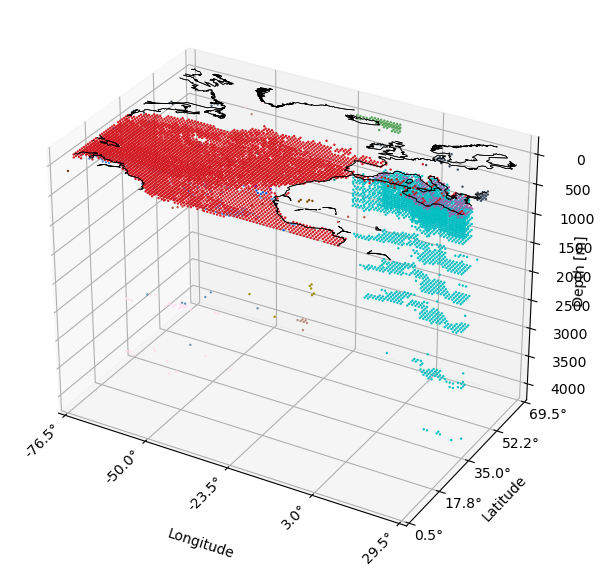

In [24]:
# Geo plot
t = endemicity_df[endemicity_df["Endemicity_Percentage"] >= 10].sort_values("Endemicity_Percentage")
plot_geo(regions_df[regions_df.label.isin(list(t.label))])

## Statistical significance analysis

In [25]:
# Count endemic species per 3D region
endemic_3d_counts = endemic_3d_species_data.groupby(["LATITUDE", "LONGITUDE", "LEV_M"])[level].nunique()

# Perform a chi-square test to check for significant clustering
chi2_stat, p_value = stats.chisquare(endemic_3d_counts)

print(f"Chi-square Statistic: {chi2_stat}, p-value: {p_value}")

if p_value < 0.05:
    print("Significant association between endemic species and 3D ocean regions.")
else:
    print("No significant association found.")


Chi-square Statistic: 147731.99213672467, p-value: 0.0
Significant association between endemic species and 3D ocean regions.
